Using device: cpu


100%|██████████| 170M/170M [01:25<00:00, 2.00MB/s]


Dataset loaded: 200 images
Generator and Discriminator created.
Epoch [1/2] D Loss: 1.0899 G Loss: 1.0455
Epoch [2/2] D Loss: 1.0867 G Loss: 0.8851


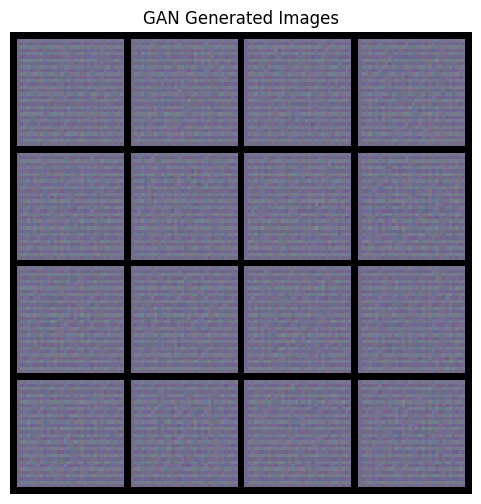

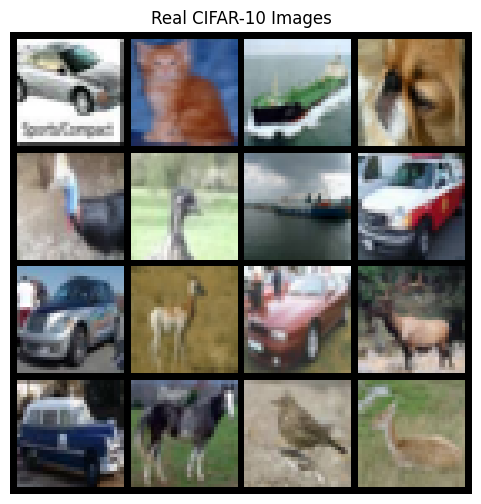

Real Image Score : 0.6612
Generated Image Score : 0.3992

GAN training and image generation completed.


In [1]:
# EXP 10: IMAGE GENERATION USING GENERATIVE ADVERSARIAL NETWORK (GAN)

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision.utils import make_grid

# --------------------------------------------------
# 1. Device
# --------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --------------------------------------------------
# 2. Load CIFAR-10 Dataset
# --------------------------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Use only 200 images for fast execution
dataset = Subset(dataset, range(200))

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

print("Dataset loaded:", len(dataset), "images")


# --------------------------------------------------
# 3. Generator
# --------------------------------------------------
class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.ConvTranspose2d(100, 64, 4, 1, 0),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.ConvTranspose2d(32, 16, 4, 2, 1),
            nn.BatchNorm2d(16),
            nn.ReLU(True),

            nn.ConvTranspose2d(16, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)


# --------------------------------------------------
# 4. Discriminator
# --------------------------------------------------
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(3, 16, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(16, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),

            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Flatten(),

            nn.Linear(64 * 4 * 4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


# Create models
G = Generator().to(device)
D = Discriminator().to(device)

print("Generator and Discriminator created.")


# --------------------------------------------------
# 5. Loss and Optimizers
# --------------------------------------------------
criterion = nn.BCELoss()

optimizer_G = optim.Adam(
    G.parameters(),
    lr=0.0002
)

optimizer_D = optim.Adam(
    D.parameters(),
    lr=0.0002
)

# --------------------------------------------------
# 6. Train GAN
# --------------------------------------------------
epochs = 2

for epoch in range(epochs):

    for real_images, _ in loader:

        real_images = real_images.to(device)

        batch_size = real_images.size(0)

        real_labels = torch.ones(
            batch_size, 1,
            device=device
        )

        fake_labels = torch.zeros(
            batch_size, 1,
            device=device
        )

        # ------------------------------------------
        # Train Discriminator
        # ------------------------------------------
        optimizer_D.zero_grad()

        real_output = D(real_images)

        real_loss = criterion(
            real_output,
            real_labels
        )

        noise = torch.randn(
            batch_size, 100, 1, 1,
            device=device
        )

        fake_images = G(noise)

        fake_output = D(
            fake_images.detach()
        )

        fake_loss = criterion(
            fake_output,
            fake_labels
        )

        d_loss = real_loss + fake_loss

        d_loss.backward()
        optimizer_D.step()

        # ------------------------------------------
        # Train Generator
        # ------------------------------------------
        optimizer_G.zero_grad()

        fake_output = D(fake_images)

        g_loss = criterion(
            fake_output,
            real_labels
        )

        g_loss.backward()
        optimizer_G.step()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"D Loss: {d_loss.item():.4f} "
        f"G Loss: {g_loss.item():.4f}"
    )


# --------------------------------------------------
# 7. Generate New Images
# --------------------------------------------------
G.eval()

with torch.no_grad():

    noise = torch.randn(
        16, 100, 1, 1,
        device=device
    )

    generated_images = G(noise)

# Convert [-1,1] -> [0,1]
generated_images = (
    generated_images + 1
) / 2

# --------------------------------------------------
# 8. Display Generated Images
# --------------------------------------------------
grid = make_grid(
    generated_images.cpu(),
    nrow=4
)

plt.figure(figsize=(6, 6))
plt.imshow(
    grid.permute(1, 2, 0)
)
plt.axis("off")
plt.title("GAN Generated Images")
plt.show()


# --------------------------------------------------
# 9. Display Real Images
# --------------------------------------------------
real_images, _ = next(iter(loader))

real_images = (
    real_images[:16] + 1
) / 2

grid_real = make_grid(
    real_images,
    nrow=4
)

plt.figure(figsize=(6, 6))
plt.imshow(
    grid_real.permute(1, 2, 0)
)
plt.axis("off")
plt.title("Real CIFAR-10 Images")
plt.show()


# --------------------------------------------------
# 10. Simple Quantitative Evaluation
# --------------------------------------------------
with torch.no_grad():

    fake_score = D(
        generated_images * 2 - 1
    ).mean().item()

    real_score = D(
        real_images * 2 - 1
    ).mean().item()

print("Real Image Score :", round(real_score, 4))
print("Generated Image Score :", round(fake_score, 4))

print("\nGAN training and image generation completed.")